# Flight Delay Prediction - Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on US domestic flight data to understand the factors driving arrival delays (>15 minutes late).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 2. Load Dataset

In [2]:
# --- PARAMETERS ---
SAMPLE_ROWS = None  # Set to None to run on the full dataset

df = pd.read_csv('../data/flight_data_2018_2024.csv')
if SAMPLE_ROWS is not None:
    df = df.sample(SAMPLE_ROWS, random_state=42).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (582425, 120)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


## 3. Data Overview & Statistics

In [3]:
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")
df.info(verbose=False)

Columns: 120
Rows: 582425
<class 'pandas.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(70), int64(23), str(27)
memory usage: 589.7 MB


In [4]:
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'TaxiOut', 'TaxiIn', 'AirTime']
df[key_cols].describe().round(2)

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn,AirTime
count,560955.00,558715.00,582425.00,560515.00,560093.00,558715.00
mean,15.97,10.66,809.34,18.98,8.28,113.29
std,66.06,68.65,588.76,11.51,6.95,70.21
min,-56.00,-90.00,31.00,1.00,1.00,7.00
25%,-6.00,-16.00,377.00,12.00,4.00,62.00
50%,-2.00,-5.00,661.00,16.00,6.00,96.00
75%,12.00,13.00,1050.00,22.00,10.00,144.00
max,3125.00,3136.00,5095.00,213.00,444.00,1338.00


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Unnamed: 119        582425
Div5Airport         582425
Div4AirportID       582425
Div4AirportSeqID    582425
Div4WheelsOn        582425
                     ...  
DepDel15             21470
DepDelayMinutes      21470
DepDelay             21470
DepTime              21396
Tail_Number           6276
Length: 75, dtype: int64


## 4. Data Cleaning & Feature Extraction

In [6]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Month'] = df['FlightDate'].dt.month
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek
df['DepHour'] = (df['CRSDepTime'] // 100).clip(0, 23)

# Filter to non-cancelled flights and drop target missing values
df_model = df[df['Cancelled'] == 0].copy()
df_model = df_model.dropna(subset=['ArrDelay', 'DepDelay'])

# Create target variable: Arrived >15 min late
df_model['ArrDel15'] = (df_model['ArrDelay'] > 15).astype(int)
print(f"Cleaned dataset shape: {df_model.shape}")
print(df_model['ArrDel15'].value_counts(normalize=True))

Cleaned dataset shape: (558715, 121)
ArrDel15
0    0.766464
1    0.233536
Name: proportion, dtype: float64


## 5. Visualizations

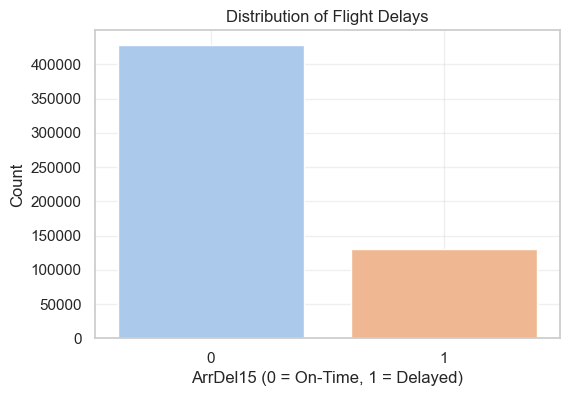

In [7]:
# Plot 1: Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='ArrDel15', data=df_model, palette='pastel')
plt.title('Distribution of Flight Delays')
plt.xlabel('ArrDel15 (0 = On-Time, 1 = Delayed)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

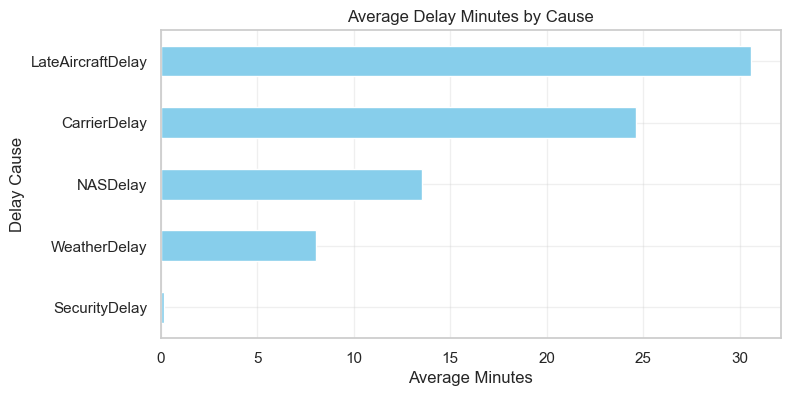

In [8]:
# Plot 2: Average Delay Cause Breakdown
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
avg_causes = df_model[delay_causes].mean()
plt.figure(figsize=(8, 4))
avg_causes.sort_values().plot(kind='barh', color='skyblue')
plt.title('Average Delay Minutes by Cause')
plt.xlabel('Average Minutes')
plt.ylabel('Delay Cause')
plt.grid(True, alpha=0.3)
plt.show()

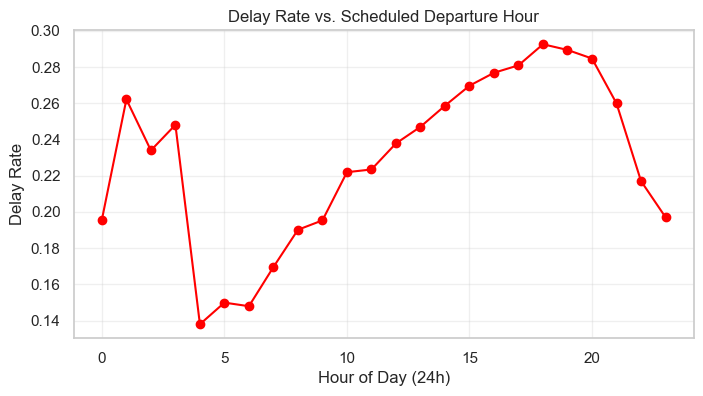

In [9]:
# Plot 3: Delay Rate by Hour of Day
plt.figure(figsize=(8, 4))
df_model.groupby('DepHour')['ArrDel15'].mean().plot(kind='line', marker='o', color='red')
plt.title('Delay Rate vs. Scheduled Departure Hour')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()

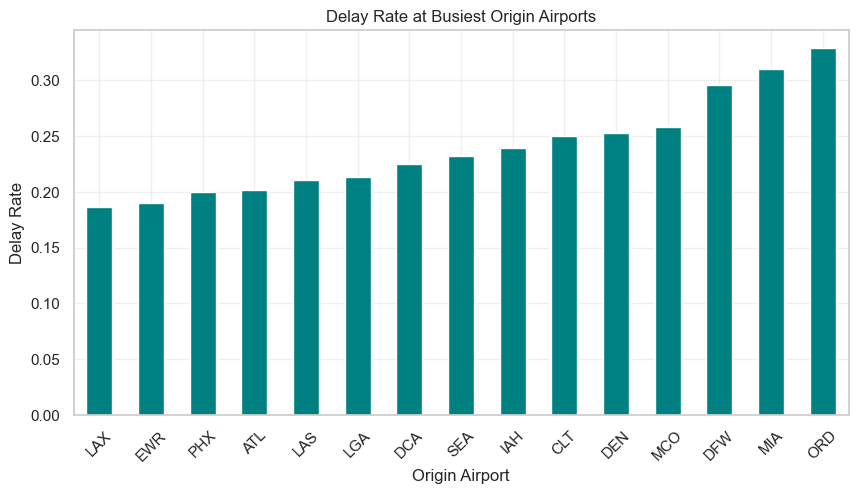

In [10]:
# Plot 4: Delay Rate for Top 15 Busiest Origin Airports
top_origins = df_model['Origin'].value_counts().head(15).index
plt.figure(figsize=(10, 5))
df_model[df_model['Origin'].isin(top_origins)].groupby('Origin')['ArrDel15'].mean().sort_values().plot(kind='bar', color='teal')
plt.title('Delay Rate at Busiest Origin Airports')
plt.xlabel('Origin Airport')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

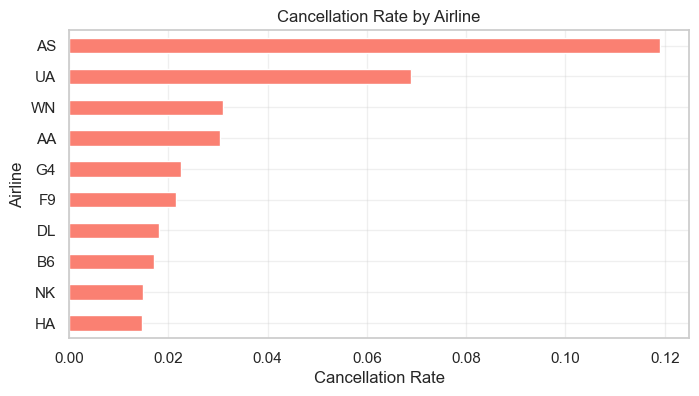

In [11]:
# Plot 5: Cancellation Rate by Airline
plt.figure(figsize=(8, 4))
df.groupby('Marketing_Airline_Network')['Cancelled'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Cancellation Rate by Airline')
plt.xlabel('Cancellation Rate')
plt.ylabel('Airline')
plt.grid(True, alpha=0.3)
plt.show()

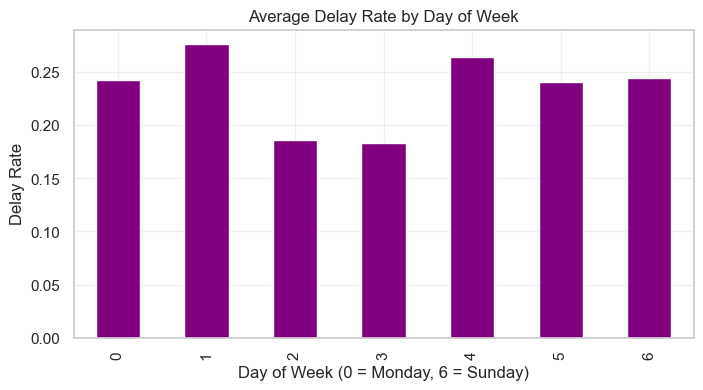

In [12]:
# Plot 6: Weekly Delay Pattern
plt.figure(figsize=(8, 4))
df_model.groupby('DayOfWeek')['ArrDel15'].mean().plot(kind='bar', color='purple')
plt.title('Average Delay Rate by Day of Week')
plt.xlabel('Day of Week (0 = Monday, 6 = Sunday)')
plt.ylabel('Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()

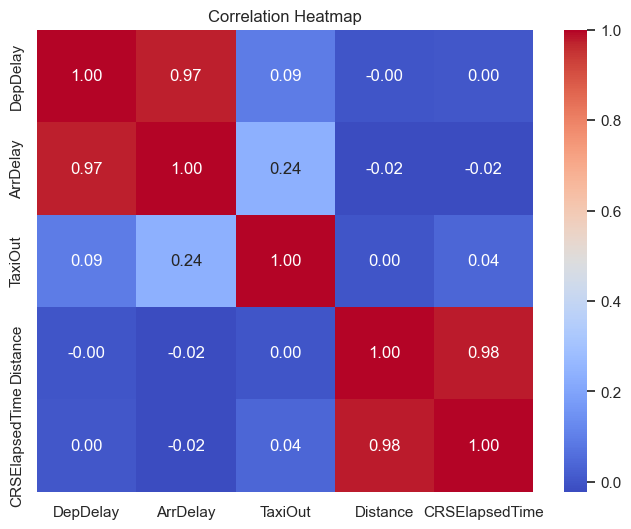

In [13]:
# Plot 7: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_cols = ['DepDelay', 'ArrDelay', 'TaxiOut', 'Distance', 'CRSElapsedTime']
sns.heatmap(df_model[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

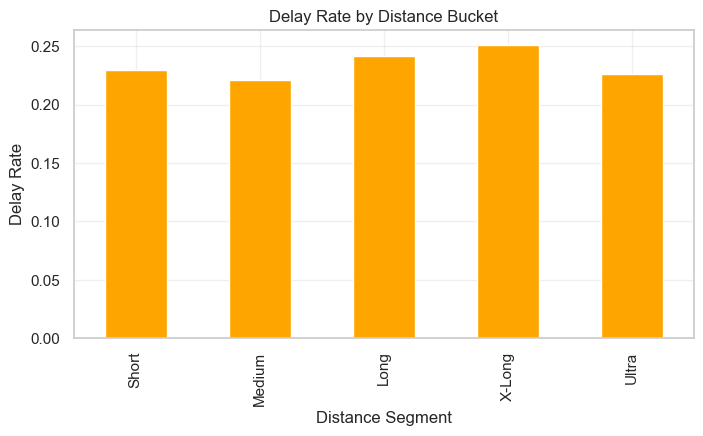

In [14]:
# Plot 8: Delay Rate by Route Distance Segment
bins = [0, 300, 600, 1000, 1500, 5000]
labels = ['Short', 'Medium', 'Long', 'X-Long', 'Ultra']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'], bins=bins, labels=labels)
plt.figure(figsize=(8, 4))
df_model.groupby('DistanceBucket', observed=True)['ArrDel15'].mean().plot(kind='bar', color='orange')
plt.title('Delay Rate by Distance Bucket')
plt.xlabel('Distance Segment')
plt.ylabel('Delay Rate')
plt.grid(True, alpha=0.3)
plt.show()